# Boostfactor calculation (Python translation)

Translation of the Julia `boostfactor calculation` notebook. It fits the transverse E-field versus z with a 1D layered model and computes the boost factor for the reduced and full bead-pull datasets stored in `ET_results.npz`.

Coordinate shift: all z-positions (mirror, disks, measurements) are shifted by +2 mm so the mirror is at z=0 and all measurement z-values are non-negative.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import spherical_jn, spherical_yn
import warnings

c_const = 299792458.0
epsilon0 = 8.854187817e-12


In [26]:
data = np.load("ET_results.npz")

nu = data["frequencies"]  # Hz
ETs_reduced = data["ETs_reduced"]  # shape (z, nu)
ETs_full = data["ETs_full"]
# Shift z by +2 mm so mirror is at 0
z_reduced_mm = data["z_reduced"] + 2.0
z_full_mm = data["z_full"] + 2.0

# Convert z to meters for the field model
z_reduced_m = z_reduced_mm * 1e-3
z_full_m = z_full_mm * 1e-3

def to_measurement_field(E):
    return np.array(E, dtype=np.complex128)

int_dA_E_reduced = to_measurement_field(ETs_reduced.T)  # (nu, z)
int_dA_E_full = to_measurement_field(ETs_full.T)        # (nu, z)

print(f"Loaded frequencies {nu.shape}, reduced {int_dA_E_reduced.shape}, full {int_dA_E_full.shape}")


Loaded frequencies (1001,), reduced (1001, 4), full (1001, 17)


In [27]:
# Geometry and material parameters (uncertainties neglected)
eps_b = 9.23
r_b = 2.93e-3 / 2.0   # bead radius [m]

J_0 = 1.0
P_in = 1.0
r_d = 0.15            # detector aperture radius [m]
A = np.pi * r_d**2

sigma_m = 5.0e7       # mirror conductivity [S/m]
eps_d = 9.3
tanD_d = 1e-5
d_d = 1e-3            # dielectric thickness [m]

n_disk = 3
z_m = 0.0             # mirror position after +2 mm shift
# Vacuum gaps stay the same physical thicknesses
_d_v_nom_mm = np.array([8.265, 9.813, 9.813])
d_v_guess = _d_v_nom_mm * 1e-3  # meters

d_v_last_ref = z_m - float(np.sum(d_v_guess + d_d))
print(f"Reference d_v_last (z_m - sum gaps) = {d_v_last_ref*1e3:.3f} mm")


Reference d_v_last (z_m - sum gaps) = -30.891 mm


## Finite-size bead factors (Mie)

Translation of the MADBead `calc_delta_e_mie` and `calc_delta_c_mie` helpers.


In [28]:
def sph_jn_ext(n, x):
    if n == -1:
        x = np.array(x, dtype=np.complex128)
        return np.cos(x) / x
    return spherical_jn(n, x)


def hn(n, x):
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)


def cn(n, x, m):
    num = (hn(n, x) * (-spherical_jn(n-1, x) + spherical_jn(n+1, x)) +
           spherical_jn(n, x) * (hn(n-1, x) - hn(n+1, x)))
    denom = (m * (-spherical_jn(n-1, m * x) + spherical_jn(n+1, m * x)) * hn(n, x) +
             spherical_jn(n, m * x) * (hn(n-1, x) - hn(n+1, x)))
    return num / denom


def dn(n, x, m):
    num = (m * x * ((-spherical_jn(n-1, x) + spherical_jn(n+1, x)) * hn(n, x) +
                spherical_jn(n, x) * (hn(n-1, x) - hn(n+1, x))))
    denom = (m * x * (-spherical_jn(n-1, m * x) + spherical_jn(n+1, m * x)) * hn(n, x) +
             spherical_jn(n, m * x) * (m**2 * x * hn(n-1, x) + (-1 + m**2) * hn(n, x) - m**2 * x * hn(n+1, x)))
    return num / denom


def Kn(n, x, m):
    A = (m**2 + 2) / (2 * x * (m**2 - 1))
    B = spherical_jn(n-1, x) * spherical_jn(n, m * x)
    C = m * spherical_jn(n, x) * spherical_jn(n-1, m * x)
    return (2 * n + 1) * A * (B - C)


def Ln(n, x, m):
    A = (m**2 + 2) / (2 * x * (m**2 - 1))
    B = sph_jn_ext(n-2, x) * sph_jn_ext(n-1, m * x)
    C = m * sph_jn_ext(n-1, x) * sph_jn_ext(n-2, m * x)
    D = spherical_jn(n, x) * spherical_jn(n+1, m * x)
    E = m * spherical_jn(n+1, x) * spherical_jn(n, m * x)
    return A * ((n + 1) * (B - C) + n * (D - E))


def calc_delta_e_mie(eps, R, f, N=3):
    k = 2 * np.pi * f / c_const
    x = k * R
    m = np.sqrt(eps)
    delta = 0.0 + 0.0j
    for n in range(1, N + 1):
        delta += (-1)**n * (Kn(n, x, m) * cn(n, x, m) - Ln(n, x, m) * dn(n, x, m))
    return delta


def calc_delta_c_mie(eps, R, f, N=3):
    k = 2 * np.pi * f / c_const
    x = k * R
    m = np.sqrt(eps)
    delta = 0.0 + 0.0j
    for n in range(1, N + 1):
        delta += (Kn(n, x, m) * cn(n, x, m) + Ln(n, x, m) * dn(n, x, m))
    return delta


delta_e = np.array([calc_delta_e_mie(eps_b, r_b, f) for f in nu])
delta_c = np.array([calc_delta_c_mie(eps_b, r_b, f) for f in nu])


## Layered 1D field model

Direct translation of `field_1D_fit.jl` to Python.


In [29]:
def fit_param_to_model(p, f):
    E_in = complex(p["E_0"])
    n_disk_local = int(p["n_disk"])

    d_v_i = [p[f"d_v_{i+1}"] for i in range(n_disk_local)]
    d_d_i = [p[f"d_d_{i+1}"] for i in range(n_disk_local)]
    eps_d_i = [p[f"eps_d_{i+1}"] for i in range(n_disk_local)]
    tanD_i = [p[f"tanD_d_{i+1}"] for i in range(n_disk_local)]

    eps_sigma = 1.0 + 1j * p["sigma_m"] / (2 * np.pi * f * epsilon0)

    if n_disk_local < 1:
        d_v_last = p["z_m"]
    else:
        d_v_last = p["z_m"] - float(np.sum(np.array(d_v_i) + np.array(d_d_i)))
    # prevent negative final gap length (would cancel stack length)
    if d_v_last < 0:
        d_v_last = 0.0

    n_region = len(d_v_i) + len(d_d_i) + 3
    distance = np.zeros(n_region, dtype=float)
    distance[1:-2:2] = d_v_i
    distance[2:-1:2] = d_d_i
    distance[-2] = d_v_last

    epsilon = np.ones(n_region, dtype=np.complex128)
    epsilon[0] = eps_sigma
    epsilon[2:-1:2] = np.array(eps_d_i) * (1.0 + 1j * np.array(tanD_i))

    return distance, epsilon, E_in


def E_field_1D_z(z, distance, epsilon, E_in, f, scale_region=2):
    k0 = 2 * np.pi * f / c_const
    nregions = len(distance)
    E = np.zeros_like(z, dtype=np.complex128)
    input_region = 2  # 1-based index from the Julia code

    n_r = np.sqrt(epsilon[0])
    rho0 = (1 - n_r) / (1 + n_r)
    RL = np.array([E_in, rho0 * E_in], dtype=np.complex128)
    E_scale = 1.0

    z_r = np.sum(distance[input_region-1:])
    idx = z > z_r
    if np.any(idx):
        z_sub = z_r - z[idx]
        E[idx] = (1 + rho0) * RL[0] * np.exp(-1j * k0 * n_r * z_sub)

    for r in range(input_region-1, nregions-1):
        if (r + 1) == scale_region:
            E_scale = RL[0]

        n_r = np.sqrt(epsilon[r])
        d_r = distance[r]
        idx = (z_r >= z) & (z > z_r - d_r)
        if np.any(idx):
            z_sub = z_r - z[idx]
            phase_term = np.exp(-1j * n_r * k0 * z_sub)
            E[idx] = RL[0] * phase_term + RL[1] * np.conj(phase_term)

        n_rp1 = np.sqrt(epsilon[r + 1])
        P_r = np.diag([np.exp(-1j * n_r * k0 * d_r), np.exp(1j * n_r * k0 * d_r)])
        G_r = 1 / (2 * n_rp1) * np.array([[n_rp1 + n_r, n_rp1 - n_r],
                                          [n_rp1 - n_r, n_rp1 + n_r]], dtype=np.complex128)
        RL = G_r @ P_r @ RL
        z_r -= d_r

    if nregions == scale_region:
        E_scale = RL[0]

    n_r = np.sqrt(epsilon[-1])
    z_r = 0.0
    idx = z < z_r
    if np.any(idx):
        z_sub = z_r - z[idx]
        phase_term = np.exp(-1j * n_r * k0 * z_sub)
        E[idx] = RL[0] * phase_term + RL[1] * np.conj(phase_term)

    return E_in / E_scale * E


def E_field2_conv_1D_z(z, distance, epsilon, E_in, f, delta=1.0 + 0.0j, delta_c=1.0 + 0.0j):
    k0 = 2 * np.pi * f / c_const
    nregions = len(distance)
    E2_conv = np.zeros_like(z, dtype=np.complex128)
    input_region = 2

    n_r = np.sqrt(epsilon[0])
    rho0 = (1 - n_r) / (1 + n_r)
    RL = np.array([E_in, rho0 * E_in], dtype=np.complex128)

    z_r = np.sum(distance[input_region-1:])
    idx = z > z_r
    if np.any(idx):
        z_sub = z_r - z[idx]
        E2_conv[idx] = (1 + rho0) * delta * RL[0]**2 * np.exp(-2j * k0 * n_r * z_sub)

    for r in range(input_region-1, nregions-1):
        n_r = np.sqrt(epsilon[r])
        d_r = distance[r]
        idx = (z_r >= z) & (z > z_r - d_r)
        if np.any(idx):
            z_sub = z_r - z[idx]
            phase_term = np.exp(-2j * n_r * k0 * z_sub)
            E2_sub = delta * (RL[0]**2 * phase_term + RL[1]**2 * np.conj(phase_term)) + 2 * delta_c * RL[0] * RL[1]
            E2_conv[idx] = E2_sub

        n_rp1 = np.sqrt(epsilon[r + 1])
        P_r = np.diag([np.exp(-1j * n_r * k0 * d_r), np.exp(1j * n_r * k0 * d_r)])
        G_r = 1 / (2 * n_rp1) * np.array([[n_rp1 + n_r, n_rp1 - n_r],
                                          [n_rp1 - n_r, n_rp1 + n_r]], dtype=np.complex128)
        RL = G_r @ P_r @ RL
        z_r -= d_r

    n_r = np.sqrt(epsilon[-1])
    z_r = 0.0
    idx = z < z_r
    if np.any(idx):
        z_sub = z_r - z[idx]
        phase_term = np.exp(-2j * n_r * k0 * z_sub)
        E2_sub = delta * (RL[0]**2 * phase_term + RL[1]**2 * np.conj(phase_term)) + 2 * delta_c * RL[0] * RL[1]
        E2_conv[idx] = E2_sub

    return E2_conv


def field_regions(distance, epsilon, E_in, f):
    k0 = 2 * np.pi * f / c_const
    nregions = len(distance)
    fr = np.zeros((nregions, 2), dtype=np.complex128)
    input_region = 2

    n_r = np.sqrt(epsilon[0])
    rho0 = (1 - n_r) / (1 + n_r)
    RL = np.array([E_in, rho0 * E_in], dtype=np.complex128)
    fr[input_region-1, :] = RL
    fr[0, :] = np.array([(1 + rho0) * RL[0], 0.0], dtype=np.complex128)

    for r in range(input_region-1, nregions-1):
        n_r = np.sqrt(epsilon[r])
        d_r = distance[r]
        n_rp1 = np.sqrt(epsilon[r + 1])
        P_r = np.diag([np.exp(-1j * n_r * k0 * d_r), np.exp(1j * n_r * k0 * d_r)])
        G_r = 1 / (2 * n_rp1) * np.array([[n_rp1 + n_r, n_rp1 - n_r],
                                          [n_rp1 - n_r, n_rp1 + n_r]], dtype=np.complex128)
        RL = G_r @ P_r @ RL
        fr[r + 1, :] = RL

    return fr


def int_dz_E_param(p, f):
    d_r, epsilon, E_in = fit_param_to_model(p, f)
    n_r = np.sqrt(epsilon)
    RL = field_regions(d_r, epsilon, E_in, f)
    R_r = RL[:, 0]
    L_r = RL[:, 1]
    k0 = 2 * np.pi * f / c_const

    intE_0 = (R_r[-1] - L_r[-1]) / n_r[-1]
    phase_term = np.exp(-1j * k0 * n_r[1:-1] * d_r[1:-1])
    intE_r = -(R_r[1:-1] * (phase_term - 1) - L_r[1:-1] * (np.conj(phase_term) - 1)) / n_r[1:-1]
    intE_m = -(R_r[0] - L_r[0]) / n_r[0]

    intE = (intE_0 + np.sum(intE_r) + intE_m) / k0
    return intE


def E_field_1D_z_param(z, p, f):
    distance, epsilon, E_in = fit_param_to_model(p, f)
    return E_field_1D_z(z, distance, epsilon, E_in, f=f)


def E_field2_conv_1D_z_param(z, p, f, delta=1.0 + 0.0j, delta_c=1.0 + 0.0j):
    distance, epsilon, E_in = fit_param_to_model(p, f)
    return E_field2_conv_1D_z(z, distance, epsilon, E_in, f=f, delta=delta, delta_c=delta_c)


## Fitting helpers

Fits each frequency independently for E_0 and the three vacuum gaps, then computes the longitudinal field integral and boost factor. Set `freq_step` to >1 to subsample frequencies for quicker test runs.


In [30]:
def build_param_dict(E0, gaps):
    p = {
        "E_0": E0,
        "z_m": z_m,
        "sigma_m": sigma_m,
        "n_disk": n_disk,
    }
    for i in range(n_disk):
        p[f"d_v_{i+1}"] = gaps[i]
        p[f"d_d_{i+1}"] = d_d
        p[f"eps_d_{i+1}"] = eps_d
        p[f"tanD_d_{i+1}"] = tanD_d
    return p


def fit_dataset(z_meters, int_dA_E, freq_indices=None):
    idxs = np.arange(len(nu)) if freq_indices is None else np.asarray(freq_indices, dtype=int)
    params = np.zeros((len(idxs), 4))
    int_dz_E = np.zeros(len(idxs), dtype=np.complex128)

    for j, fi in enumerate(idxs):
        f = nu[fi]
        y = np.abs(int_dA_E[fi])
        E0_init = 0.5 * np.mean(y) if np.mean(y) > 0 else 1.0

        def model(z, E0, d1, d2, d3):
            p = build_param_dict(E0, [d1, d2, d3])
            distance, epsilon, E_in = fit_param_to_model(p, f)
            z_total = np.sum(distance[1:])
            z_use = np.clip(z, 0.0, max(z_total - 1e-9, 0.0))
            E_conv = E_field2_conv_1D_z(z_use, distance, epsilon, E_in,
                                     f=f, delta=delta_e[fi], delta_c=delta_c[fi])
            return np.sqrt(np.abs(E_conv))

        try:
            popt, _ = curve_fit(
                model,
                z_meters,
                y,
                p0=[E0_init, *d_v_guess],
                bounds=(0, np.inf),
                maxfev=8000,
            )
        except Exception as exc:
            warnings.warn(f"Fit failed at f={f/1e9:.3f} GHz: {exc}")
            popt = np.array([E0_init, *d_v_guess])

        params[j] = popt
        p_fit = build_param_dict(popt[0], popt[1:])
        int_dz_E[j] = int_dz_E_param(p_fit, f=f)

    int_dV_E = np.abs(int_dz_E)
    P_sig = (J_0**2) / (16 * P_in) * np.abs(int_dz_E)**2
    P_0 = c_const * A * J_0**2 / (2 * epsilon0 * (2 * np.pi * nu[idxs])**2)
    boost = P_sig / P_0

    return {
        "freq_indices": idxs,
        "params": params,
        "int_dz_E": int_dz_E,
        "int_dV_E": int_dV_E,
        "boostfactor": boost,
    }


freq_step = 1  # increase to speed up test runs
freq_indices = np.arange(0, len(nu), freq_step)

results = {
    "reduced": fit_dataset(z_reduced_m, int_dA_E_reduced, freq_indices=freq_indices),
    "full": fit_dataset(z_full_m, int_dA_E_full, freq_indices=freq_indices),
}


C:\Users\nabil\AppData\Local\Temp\ipykernel_10568\1580634891.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


## Quick looks

Magnitude of the integrated transverse field and the resulting boost factor.


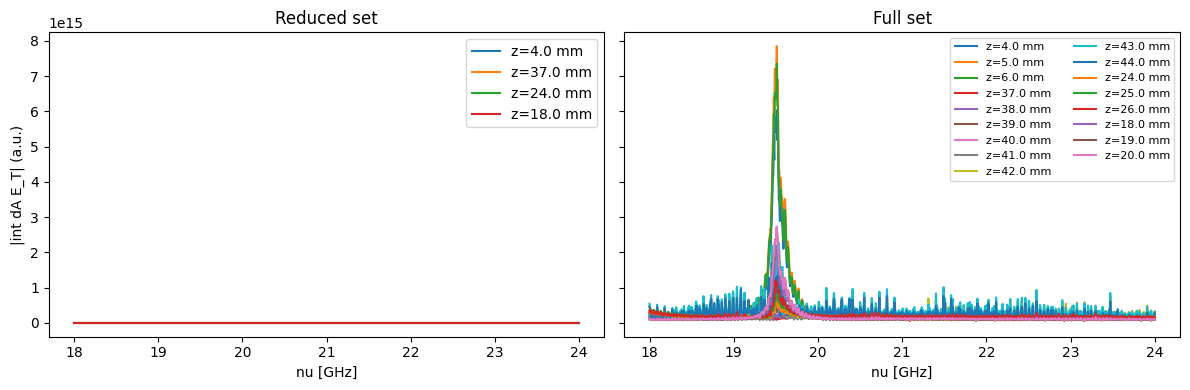

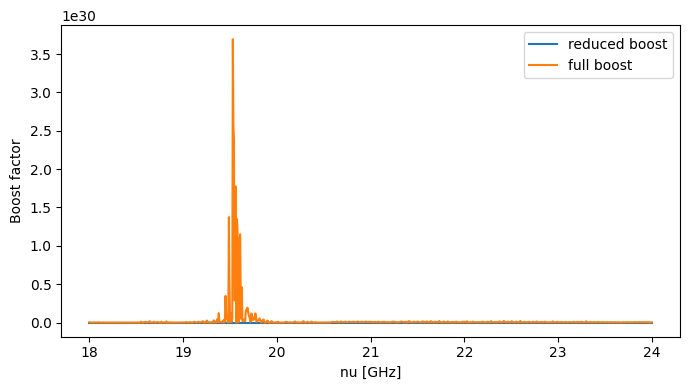

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for j, zmm in enumerate(z_reduced_mm):
    ax[0].plot(nu[freq_indices] * 1e-9, np.abs(int_dA_E_reduced[freq_indices, j]), label=f"z={zmm:.1f} mm")
ax[0].set_title("Reduced set")
ax[0].set_xlabel("nu [GHz]")
ax[0].set_ylabel("|int dA E_T| (a.u.)")
ax[0].legend()

for j, zmm in enumerate(z_full_mm):
    ax[1].plot(nu[freq_indices] * 1e-9, np.abs(int_dA_E_full[freq_indices, j]), label=f"z={zmm:.1f} mm")
ax[1].set_title("Full set")
ax[1].set_xlabel("nu [GHz]")
ax[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for label, res in results.items():
    plt.plot(nu[res["freq_indices"]] * 1e-9, res["boostfactor"], label=f"{label} boost")
plt.xlabel("nu [GHz]")
plt.ylabel("Boost factor")
plt.legend()
plt.tight_layout()
plt.show()


## Example single-frequency fit

Displays the fit with the largest recovered |E_0| for the chosen dataset.
Measurement points use the left y-axis; fit curves use a separate right y-axis.


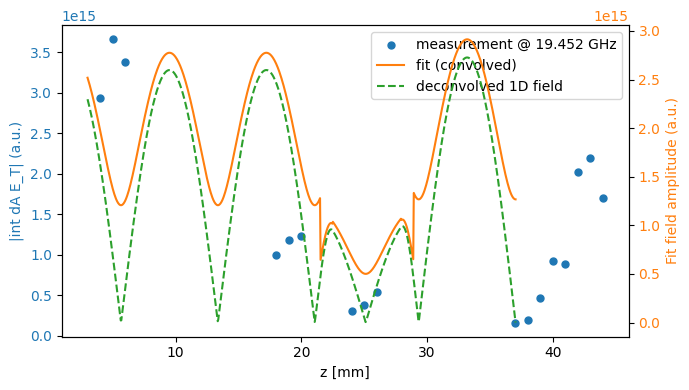

In [32]:
label = "full"  # set to "reduced" to inspect the reduced data
res = results[label]
z_meas_m = z_full_m if label == "full" else z_reduced_m
int_dA_E_meas = int_dA_E_full if label == "full" else int_dA_E_reduced

idx_local = np.argmax(np.abs(res["params"][:, 0]))
f_idx = res["freq_indices"][idx_local]
popt = res["params"][idx_local]
p_fit = build_param_dict(popt[0], popt[1:])

# Restrict visualization grid to the physical region z >= 0 (mirror at 0)
z_grid_min = max(0.0, z_meas_m.min() - 1e-3)
z_grid_max = z_meas_m.max() + 0.01
# clamp plot grid to stack length
distance, epsilon, E_in = fit_param_to_model(p_fit, f=nu[f_idx])
z_total = np.sum(distance[1:])
z_grid_max = min(z_grid_max, z_total)
z_grid = np.linspace(z_grid_min, z_grid_max, 800)

E_fit = np.sqrt(np.abs(E_field2_conv_1D_z(z_grid, distance, epsilon, E_in, f=nu[f_idx], delta=delta_e[f_idx], delta_c=delta_c[f_idx])))
E_deconv = np.abs(E_field_1D_z(z_grid, distance, epsilon, E_in, f=nu[f_idx]))

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

c_meas = "tab:blue"
c_fit = "tab:orange"
c_deconv = "tab:green"

sc = ax1.scatter(z_meas_m * 1e3, np.abs(int_dA_E_meas[f_idx]), s=25, color=c_meas,
                label=f"measurement @ {nu[f_idx]/1e9:.3f} GHz")
l_fit, = ax2.plot(z_grid * 1e3, E_fit, color=c_fit, label="fit (convolved)")
l_dec, = ax2.plot(z_grid * 1e3, E_deconv, color=c_deconv, linestyle="--", label="deconvolved 1D field")

ax1.set_xlabel("z [mm]")
ax1.set_ylabel("|int dA E_T| (a.u.)", color=c_meas)
ax2.set_ylabel("Fit field amplitude (a.u.)", color=c_fit)
ax1.tick_params(axis="y", labelcolor=c_meas)
ax2.tick_params(axis="y", labelcolor=c_fit)

handles = [sc, l_fit, l_dec]
ax1.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()


## Optional: save fitted results for reuse


In [ ]:
np.savez(
    "boostfactor_results_python.npz",
    freq=nu[freq_indices],
    params_reduced=results["reduced"]["params"],
    params_full=results["full"]["params"],
    boost_reduced=results["reduced"]["boostfactor"],
    boost_full=results["full"]["boostfactor"],
    int_dz_E_reduced=results["reduced"]["int_dz_E"],
    int_dz_E_full=results["full"]["int_dz_E"],
)
print("Saved boostfactor_results_python.npz")
